# Lofted Surface Voronoi Generation

This notebook builds a lofted surface from 8 circles defined by radii in `data/lofted_surface_inputs.json`. Each circle is created on the `XY` plane around the origin and then translated along `Z` in fixed `12` unit increments: `0, 12, 24, ...`.

The loft is sliced by the `YZ` plane through the origin, one side is kept, a padded bounding box is filled with random points from `data/voronoi_points_inputs.json`, a bounded 3D Voronoi diagram is generated, and the cells are intersected with the kept half of the loft. Any later non-uniform scaling uses the center of the initial loft bounding box as its pivot, scales only in `X` and `Y`, and keeps `Z` unchanged.

All intersection curves that hit the kept shape are retained. Closed curves stay closed, and open curves are closed by connecting their endpoints with one straight segment. Only cells with no intersection at all are discarded. The final output is shown as a shaded static render so it remains visible even when notebook widget rendering is unreliable.

In [1]:
import colorsys
import tempfile
from dataclasses import replace
from pathlib import Path
from uuid import uuid4

import ipywidgets as widgets
import numpy as np
import pyvista as pv
from IPython.display import Image, Markdown, display

from compass_web.lofted_surface_voronoi import (
    _build_staged_offset_lofts,
    _extract_polylines,
    _fan_surface_from_center,
    _loft_between_polylines,
    _merge_meshes,
    analyze_and_generate_surfaces,
    build_bounded_voronoi_cells,
    build_lofted_surface,
    build_polyline_mesh,
    clip_surface_in_half,
    intersect_cells_with_surface,
    load_generation_config,
    load_voronoi_point_config,
    pad_bounds,
    random_points_in_bounds,
    rebuild_polylines_from_discontinuities,
)

pv.set_plot_theme("document")

MAX_MODEL_SPAN = 150.0
MIN_RADIUS = 5.0
MAX_RADIUS = 70.0
MAX_Z_INCREMENT = MAX_MODEL_SPAN / 7.0
SMALL_CELL_EXTRUSION_FACTOR = 0.1

surface_config_path = Path("data/lofted_surface_inputs.json")
point_config_path = Path("data/voronoi_points_inputs.json")
surface_config = load_generation_config(surface_config_path)
point_config = load_voronoi_point_config(point_config_path)


def make_float_control(
    *,
    value: float,
    min_value: float,
    max_value: float,
    step: float,
    description: str,
    readout_format: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.FloatSlider, widgets.BoundedFloatText]:
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    # The bounded text box gives a direct click-and-type way to enter exact values.
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


def make_int_control(
    *,
    value: int,
    min_value: int,
    max_value: int,
    step: int,
    description: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.IntSlider, widgets.BoundedIntText]:
    slider = widgets.IntSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedIntText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


radius_controls = [
    make_float_control(
        value=float(radius),
        min_value=MIN_RADIUS,
        max_value=MAX_RADIUS,
        step=0.001,
        description=f"R{i + 1}",
        readout_format=".3f",
    )
    for i, radius in enumerate(surface_config.radii)
]
radius_rows = [row for row, _, _ in radius_controls]
radius_sliders = [slider for _, slider, _ in radius_controls]

spacing_row, spacing_slider, _ = make_float_control(
    value=float(surface_config.z_increment),
    min_value=4.0,
    max_value=MAX_Z_INCREMENT,
    step=0.01,
    description="Spacing",
    readout_format=".2f",
)
point_count_row, point_count_slider, _ = make_int_control(
    value=int(point_config.seed_count),
    min_value=2,
    max_value=300,
    step=1,
    description="Points",
)
seed_row, seed_slider, _ = make_int_control(
    value=int(point_config.random_seed),
    min_value=0,
    max_value=9999,
    step=1,
    description="Seed",
)
extrusion_row, extrusion_multiplier_slider, _ = make_float_control(
    value=-0.2,
    min_value=-3.0,
    max_value=3.0,
    step=0.05,
    description="Extrude",
    readout_format=".2f",
)
scale_x_row, scale_x_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale X",
    readout_format=".2f",
)
scale_y_row, scale_y_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale Y",
    readout_format=".2f",
)


def validate_geometry_limits(radii: tuple[float, ...], z_increment: float) -> tuple[float, float]:
    max_width = 2.0 * max(radii)
    max_height = z_increment * (len(radii) - 1)
    if max_width > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The widest circle would produce {max_width:.2f} units in width, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    if max_height > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The stacked circles would span {max_height:.2f} units in Z, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    return max_width, max_height


def get_active_surface_config():
    radii = tuple(float(slider.value) for slider in radius_sliders)
    z_increment = float(spacing_slider.value)
    validate_geometry_limits(radii, z_increment)
    z_levels = tuple(index * z_increment for index in range(len(radii)))
    return replace(surface_config, radii=radii, z_increment=z_increment, z_levels=z_levels)


def get_active_point_config():
    return replace(
        point_config,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
    )


def get_extrusion_multiplier() -> float:
    return float(extrusion_multiplier_slider.value)


def get_planar_scales() -> tuple[float, float]:
    return float(scale_x_slider.value), float(scale_y_slider.value)


def scale_points_in_xy(
    points: np.ndarray,
    center: np.ndarray,
    scale_x: float,
    scale_y: float,
) -> np.ndarray:
    scaled_points = np.asarray(points, dtype=float).copy()
    scaled_points[:, 0] = center[0] + scale_x * (scaled_points[:, 0] - center[0])
    scaled_points[:, 1] = center[1] + scale_y * (scaled_points[:, 1] - center[1])
    return scaled_points


def scale_polydata_in_xy(
    mesh: pv.PolyData,
    center: np.ndarray,
    scale_x: float,
    scale_y: float,
) -> pv.PolyData:
    if mesh.n_points == 0:
        return pv.PolyData()
    scaled = mesh.copy(deep=True)
    # Keep the original topology untouched so the scaled boundary loops stay one-to-one with the source loops.
    scaled.points = scale_points_in_xy(
        mesh.points,
        center=center,
        scale_x=scale_x,
        scale_y=scale_y,
    )
    return scaled


def count_connected_regions(mesh: pv.PolyData) -> int:
    if mesh.n_cells == 0:
        return 0
    connected = mesh.connectivity()
    region_ids = np.asarray(connected["RegionId"], dtype=int)
    return int(np.unique(region_ids).size) if region_ids.size > 0 else 0


def extract_naked_edge_loops(surface: pv.PolyData, tolerance: float) -> tuple[pv.PolyData, list[np.ndarray]]:
    if surface.n_points == 0:
        return pv.PolyData(), []
    boundary_edges = surface.extract_feature_edges(
        boundary_edges=True,
        feature_edges=False,
        manifold_edges=False,
        non_manifold_edges=False,
    ).clean()
    polylines = _extract_polylines(boundary_edges, tolerance=tolerance)
    return build_polyline_mesh(polylines), polylines


def polyline_point_keys(polyline: np.ndarray, tolerance: float) -> set[tuple[int, int, int]]:
    unique_points = polyline[:-1] if len(polyline) > 1 else polyline
    return {
        tuple(np.round(np.asarray(point, dtype=float) / tolerance).astype(int).tolist())
        for point in unique_points
    }


def filter_isolated_polylines(
    polylines: list[np.ndarray],
    tolerance: float,
) -> tuple[list[np.ndarray], list[int], list[int]]:
    if not polylines:
        return [], [], []
    point_key_sets = [polyline_point_keys(polyline, tolerance=tolerance) for polyline in polylines]
    kept_indices: list[int] = []
    discarded_indices: list[int] = []
    for index, point_keys in enumerate(point_key_sets):
        has_neighbor = any(
            index != other_index and len(point_keys.intersection(other_point_keys)) > 0
            for other_index, other_point_keys in enumerate(point_key_sets)
        )
        if has_neighbor:
            kept_indices.append(index)
        else:
            discarded_indices.append(index)
    return [polylines[index] for index in kept_indices], kept_indices, discarded_indices


def export_mesh_to_stl(mesh: pv.PolyData, output_path: str | Path) -> Path:
    if mesh.n_points == 0 or mesh.n_cells == 0:
        raise ValueError("Cannot export an empty mesh to STL.")
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)
    mesh.extract_surface(algorithm="dataset_surface").triangulate().clean().save(str(output))
    return output


display(
    Markdown(
        "### Geometry Controls\n\n"
        "These controls override the JSON defaults for this notebook run only. "
        "Every slider also has a bounded number field on the right so you can click and type exact values.\n\n"
        f"Design guardrails: total width must stay at or below {MAX_MODEL_SPAN:.0f} units and total Z height must also stay at or below {MAX_MODEL_SPAN:.0f} units. "
        "Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. "
        "The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged."
    )
)
display(
    widgets.VBox(
        [
            *radius_rows,
            spacing_row,
            point_count_row,
            seed_row,
            extrusion_row,
            scale_x_row,
            scale_y_row,
        ]
    )
)
(surface_config, point_config)


### Geometry Controls

These controls override the JSON defaults for this notebook run only. Every slider also has a bounded number field on the right so you can click and type exact values.

Design guardrails: total width must stay at or below 150 units and total Z height must also stay at or below 150 units. Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged.

(LoftedVoronoiConfig(radii=(8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46), z_levels=(0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001), z_increment=13.38, circle_resolution=120, slice_normal=(1.0, 0.0, 0.0), slice_origin=(0.0, 0.0, 0.0), bbox_padding=4.0, line_tolerance=0.001),
 VoronoiPointConfig(seed_count=78, random_seed=12))

In [2]:
# Read the latest widget values once so every downstream cell works from the same inputs.
active_surface_config = get_active_surface_config()
active_point_config = get_active_point_config()
raw_extrusion_multiplier = get_extrusion_multiplier()
extrusion_multiplier = 5.0 * raw_extrusion_multiplier
scale_x, scale_y = get_planar_scales()

# The widest section controls the total width because all circles are centered on the origin.
current_width = 2.0 * max(active_surface_config.radii)
current_height = active_surface_config.z_levels[-1] - active_surface_config.z_levels[0]

# Build the full loft first, then clip it in half along the YZ plane.
full_surface = build_lofted_surface(active_surface_config)
full_loft_bounds = full_surface.bounds
initial_loft_bbox_center = np.array(
    [
        0.5 * (full_loft_bounds[0] + full_loft_bounds[1]),
        0.5 * (full_loft_bounds[2] + full_loft_bounds[3]),
        0.5 * (full_loft_bounds[4] + full_loft_bounds[5]),
    ],
    dtype=float,
)
half_surface = clip_surface_in_half(
    full_surface,
    normal=active_surface_config.slice_normal,
    origin=active_surface_config.slice_origin,
)

# A slightly larger box is used later so the Voronoi cells stay finite before intersection.
padded_bounds = pad_bounds(half_surface.bounds, active_surface_config.bbox_padding)

print(f"Radii: {list(active_surface_config.radii)}")
print(f"Z positions: {list(active_surface_config.z_levels)}")
print(f"Current width: {current_width:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Current height: {current_height:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Slice plane: YZ at x = {active_surface_config.slice_origin[0]}")
print(f"Voronoi seed points: {active_point_config.seed_count}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Extrusion slider value: {raw_extrusion_multiplier:.2f}")
print(f"Effective extrusion multiplier (x5): {extrusion_multiplier:.2f}")
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Full loft surface: {full_surface.n_points} points / {full_surface.n_cells} cells")
print(f"Kept half surface: {half_surface.n_points} points / {half_surface.n_cells} cells")
print(f"Padded bounds: {padded_bounds}")


Radii: [8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46]
Z positions: [0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001]
Current width: 38.60 / 150
Current height: 93.66 / 150
Slice plane: YZ at x = 0.0
Voronoi seed points: 78
Voronoi random seed: 12
Extrusion slider value: -0.20
Effective extrusion multiplier (x5): -1.00
Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 46.830000000000005]
Full loft surface: 960 points / 1680 cells
Kept half surface: 510 points / 868 cells
Padded bounds: (-4.0, 23.299, -23.299, 23.299, -4.0, 97.66000000000001)


In [3]:
# Fill the padded box with random points. These points are the seeds that define the Voronoi cells.
seed_points = random_points_in_bounds(
    bounds=padded_bounds,
    count=active_point_config.seed_count,
    seed=active_point_config.random_seed,
)

# Build finite Voronoi cells inside the padded box, then intersect them with the clipped loft.
voronoi_cells = build_bounded_voronoi_cells(seed_points, padded_bounds)
raw_closed_polylines = intersect_cells_with_surface(
    surface=half_surface,
    cells=voronoi_cells,
    tolerance=active_surface_config.line_tolerance,
)
closed_polylines, kept_polyline_indices, discarded_polyline_indices = filter_isolated_polylines(
    raw_closed_polylines,
    tolerance=active_surface_config.line_tolerance,
)
retained_intersection_polyline_count = len(closed_polylines)
polyline_snap_tolerance = max(20.0 * active_surface_config.line_tolerance, 0.02)
closed_polylines = rebuild_polylines_from_discontinuities(
    closed_polylines,
    tolerance=active_surface_config.line_tolerance,
    discontinuity_angle_degrees=176.0,
    neighbor_snap_tolerance=polyline_snap_tolerance,
)
polyline_mesh = build_polyline_mesh(closed_polylines)
discarded_polyline_mesh = build_polyline_mesh([raw_closed_polylines[index] for index in discarded_polyline_indices])

print(f"Random seed points: {len(seed_points)}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Bounded Voronoi cells: {len(voronoi_cells)}")
print(f"Raw surface intersection polylines: {len(raw_closed_polylines)}")
print(f"Surface intersection polylines kept after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(closed_polylines)}")
print(f"Polyline snap tolerance used: {polyline_snap_tolerance:.4f}")
print(f"Discarded isolated polylines: {len(discarded_polyline_indices)}")
print(f"Polyline mesh lines: {polyline_mesh.n_lines}")


Random seed points: 78
Voronoi random seed: 12
Bounded Voronoi cells: 78
Raw surface intersection polylines: 52
Surface intersection polylines kept after neighbor filter: 51
Rebuilt line polylines used downstream: 51
Polyline snap tolerance used: 0.0200
Discarded isolated polylines: 1
Polyline mesh lines: 51


In [4]:
# Analyze each retained curve and generate the derived surface patches.
curve_result = analyze_and_generate_surfaces(
    closed_polylines,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    extrusion_scale_origin=initial_loft_bbox_center,
    planar_scale_factors=(scale_x, scale_y),
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_original_polylines = [analysis.original_polyline for analysis in curve_result.analyses]
analysis_followup_polylines = [analysis.followup_polyline for analysis in curve_result.analyses]
followup_polyline_mesh = build_polyline_mesh(list(curve_result.followup_polylines))
bbox_edge_meshes = [analysis.bbox_mesh.extract_all_edges() for analysis in curve_result.analyses]
circle_centers = np.array([analysis.circle_center for analysis in curve_result.analyses], dtype=float)
scaled_circle_centers = np.array([analysis.scaled_circle_center for analysis in curve_result.analyses], dtype=float)
extrusion_base_vectors = np.array([analysis.extrusion_base_vector for analysis in curve_result.analyses], dtype=float)
extrusion_base_lengths = np.linalg.norm(extrusion_base_vectors, axis=1) if len(curve_result.analyses) > 0 else np.zeros(0, dtype=float)
curve_lengths = np.array([analysis.curve_length for analysis in curve_result.analyses], dtype=float)
bbox_volumes = np.array([analysis.bbox_volume for analysis in curve_result.analyses], dtype=float)
ratios = np.array([analysis.ratio for analysis in curve_result.analyses], dtype=float)
sorted_indices = np.argsort(ratios)[::-1]
large_curve_count = sum(analysis.ratio >= curve_result.average_ratio for analysis in curve_result.analyses)
small_curve_count = len(curve_result.analyses) - large_curve_count
discontinuity_point_sets = [analysis.discontinuity_points for analysis in curve_result.analyses]
all_discontinuity_points = (
    np.vstack([points for points in discontinuity_point_sets if len(points) > 0])
    if any(len(points) > 0 for points in discontinuity_point_sets)
    else np.zeros((0, 3), dtype=float)
)
curve_colors = [
    "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / len(curve_result.analyses), 0.7, 1.0))
    for index in range(len(curve_result.analyses))
] if curve_result.analyses else []
curve_label_points = np.array([
    analysis.followup_polyline[:-1].mean(axis=0) for analysis in curve_result.analyses
], dtype=float) if curve_result.analyses else np.zeros((0, 3), dtype=float)
curve_labels = [f"crv {index + 1}" for index in range(len(curve_result.analyses))]
analysis_output_meshes: list[pv.PolyData] = []
analysis_preview_output_meshes: list[pv.PolyData] = []
analysis_output_modes: list[str] = []
for analysis in curve_result.analyses:
    if analysis.ratio >= curve_result.average_ratio:
        offset_vector = extrusion_multiplier * analysis.extrusion_base_vector
        # Large curves now use two moved scaled polylines so the open patch is lofted in two consecutive bands.
        staged_mesh, _, _ = _build_staged_offset_lofts(
            analysis.followup_polyline,
            center=analysis.circle_center,
            plane_u=analysis.plane_u,
            plane_v=analysis.plane_v,
            offset_vector=offset_vector,
        )
        analysis_preview_output_meshes.append(staged_mesh)
        analysis_output_meshes.append(staged_mesh)
        analysis_output_modes.append("large")
    else:
        offset_vector = SMALL_CELL_EXTRUSION_FACTOR * extrusion_multiplier * analysis.extrusion_base_vector
        # Small curves collapse to a fan so they become simpler accent features.
        moved_center = analysis.circle_center + offset_vector
        fan_mesh = _fan_surface_from_center(moved_center, analysis.discontinuity_points)
        analysis_preview_output_meshes.append(fan_mesh)
        analysis_output_meshes.append(fan_mesh)
        analysis_output_modes.append("small")

generated_surface = curve_result.generated_surface if curve_result.generated_surface.n_points else half_surface
generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

print(f"Analyzed curves: {len(curve_result.analyses)}")
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier used: {extrusion_multiplier:.2f}")
print(f"Small-cell extrusion factor: {SMALL_CELL_EXTRUSION_FACTOR:.2f}")
print(f"Scaled-center extrusion pivot: {initial_loft_bbox_center.tolist()}")
print(f"Planar scaling used for center vectors (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Curves classified as large: {large_curve_count}")
print(f"Curves classified as small: {small_curve_count}")
print(f"Generated surface faces: {curve_result.generated_surface.n_cells}")
print(f"Large-curve loft faces: {curve_result.larger_surface.n_cells}")
print(f"Small-curve fan faces: {curve_result.smaller_surface.n_cells}")
if len(extrusion_base_lengths) > 0:
    print(
        f"Scaled-center vector lengths - min: {extrusion_base_lengths.min():.3f}, "
        f"max: {extrusion_base_lengths.max():.3f}, "
        f"mean: {extrusion_base_lengths.mean():.3f}"
    )
if curve_result.followup_polylines:
    print(
        f"Working polyline segments - min: {min(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"max: {max(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"mean: {np.mean([len(polyline) - 1 for polyline in curve_result.followup_polylines]):.1f}"
    )
else:
    print("Working polyline segments: no retained curves were generated.")
print(f"Discontinuity markers total: {len(all_discontinuity_points)}")

top_count = min(8, len(sorted_indices))
summary_rows = [
    (
        int(index),
        float(ratios[index]),
        float(bbox_volumes[index]),
        float(curve_lengths[index]),
    )
    for index in sorted_indices[:top_count]
]
summary_rows


Analyzed curves: 51
Average volume/length ratio: 7.8474
Extrusion multiplier used: -1.00
Small-cell extrusion factor: 0.10
Scaled-center extrusion pivot: [0.0, 0.0, 46.830000000000005]
Planar scaling used for center vectors (X, Y) with Z fixed: (0.50, 0.50)
Curves classified as large: 21
Curves classified as small: 30
Generated surface faces: 2472
Large-curve loft faces: 2112
Small-curve fan faces: 360
Scaled-center vector lengths - min: 3.281, max: 9.325, mean: 6.521
Working polyline segments - min: 3, max: 41, mean: 17.8
Discontinuity markers total: 908


[(41, 35.64886333710609, 2232.123348292467, 62.61415201895374),
 (20, 26.932525213523004, 1554.6097910809362, 57.72239248848289),
 (37, 26.223838177599113, 1403.3444908089336, 53.51407682219823),
 (9, 25.835525035773607, 1447.3738678510413, 56.02262256512728),
 (11, 22.54743235105585, 1151.6338701901543, 51.07605390536744),
 (30, 22.24505402337992, 1168.0954018185823, 52.5103423255747),
 (16, 21.424221427211066, 1037.347165298109, 48.41936351444569),
 (25, 19.084803379295586, 992.3308393691851, 51.99586391577547)]

In [5]:
def distinct_colors(count: int) -> list[str]:
    if count <= 0:
        return []
    return [
        "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / count, 0.7, 1.0))
        for index in range(count)
    ]


def camera_position_from_bounds(
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
) -> list[list[float]]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    max_span = max(xmax - xmin, ymax - ymin, zmax - zmin, 1.0)
    target_array = np.asarray(target, dtype=float)
    # This keeps a readable three-quarter view while allowing the fitted bounds to control the final framing.
    camera_position = target_array + np.array([1.05 * max_span, -1.45 * max_span, 0.78 * max_span], dtype=float)
    return [camera_position.tolist(), target_array.tolist(), [0.0, 0.0, 1.0]]


def merge_bounds(bounds_list: list[tuple[float, float, float, float, float, float]]) -> tuple[float, float, float, float, float, float]:
    if not bounds_list:
        raise ValueError("bounds_list must not be empty.")
    mins = np.array([[bounds[0], bounds[2], bounds[4]] for bounds in bounds_list], dtype=float)
    maxs = np.array([[bounds[1], bounds[3], bounds[5]] for bounds in bounds_list], dtype=float)
    min_corner = mins.min(axis=0)
    max_corner = maxs.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def bounds_from_points(points: np.ndarray) -> tuple[float, float, float, float, float, float] | None:
    if len(points) == 0:
        return None
    points_array = np.asarray(points, dtype=float)
    min_corner = points_array.min(axis=0)
    max_corner = points_array.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def padded_scene_bounds(
    bounds: tuple[float, float, float, float, float, float],
    padding_fraction: float = 0.22,
    min_padding: float = 1.0,
) -> tuple[float, float, float, float, float, float]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    spans = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    padding = np.maximum(spans * padding_fraction, min_padding)
    return (
        float(xmin - padding[0]),
        float(xmax + padding[0]),
        float(ymin - padding[1]),
        float(ymax + padding[1]),
        float(zmin - padding[2]),
        float(zmax + padding[2]),
    )


def center_from_bounds(bounds: tuple[float, float, float, float, float, float]) -> np.ndarray:
    return np.array(
        [
            0.5 * (bounds[0] + bounds[1]),
            0.5 * (bounds[2] + bounds[3]),
            0.5 * (bounds[4] + bounds[5]),
        ],
        dtype=float,
    )


def add_scene_content(
    plotter: pv.Plotter,
    *,
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
) -> None:
    for mesh, kwargs in meshes or []:
        if mesh.n_points == 0:
            continue
        plotter.add_mesh(mesh, **kwargs)

    for line_mesh, kwargs in line_meshes or []:
        if line_mesh.n_points == 0:
            continue
        plotter.add_mesh(line_mesh, render_lines_as_tubes=True, **kwargs)

    for points, kwargs in point_sets or []:
        if len(points) == 0:
            continue
        plotter.add_points(np.asarray(points, dtype=float), **kwargs)

    for points, labels, kwargs in label_sets or []:
        if len(points) == 0 or not labels:
            continue
        plotter.add_point_labels(np.asarray(points, dtype=float), labels, **kwargs)


def render_static_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.1,
    window_size: tuple[int, int] = (1100, 820),
) -> bytes:
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )

    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    # Static images have no orbit controls, so a mild zoom helps the fitted scene occupy more of the screenshot.
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")

    image_path = Path(tempfile.gettempdir()) / f"{uuid4().hex}.png"
    try:
        plotter.screenshot(str(image_path))
        return image_path.read_bytes()
    finally:
        plotter.close()
        image_path.unlink(missing_ok=True)


def display_static_scene(**kwargs: object) -> None:
    display(Image(data=render_static_scene(**kwargs)))


def display_interactive_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.0,
    window_size: tuple[int, int] = (1200, 900),
) -> None:
    # PyVista's notebook html/trame backends are not available in this environment,
    # so the interactive inspection opens in a native VTK window instead.
    plotter = pv.Plotter(notebook=False, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )
    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")
    plotter.show()


def selected_curve_indices(curve_index: int, curve_count: int, show_all_up_to: bool) -> list[int]:
    if curve_index <= 0:
        return []
    if show_all_up_to:
        return list(range(min(curve_index, curve_count)))
    return [min(curve_index, curve_count) - 1]


def build_selected_discontinuity_points(indices: list[int]) -> np.ndarray:
    selected_sets = [discontinuity_point_sets[index] for index in indices if len(discontinuity_point_sets[index]) > 0]
    if not selected_sets:
        return np.zeros((0, 3), dtype=float)
    return np.vstack(selected_sets)


def build_selected_centers(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return circle_centers[indices]


def build_selected_curve_label_points(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return curve_label_points[indices]


def build_selected_curve_labels(indices: list[int]) -> list[str]:
    return [curve_labels[index] for index in indices]


def build_selected_curve_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            build_polyline_mesh([analysis_followup_polylines[index]]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index in indices
    ]


def build_selected_output_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            analysis_preview_output_meshes[index],
            {
                "color": curve_colors[index],
                "opacity": 1.0,
                "smooth_shading": True,
            },
        )
        for index in indices
        if analysis_preview_output_meshes[index].n_points > 0
    ]


def selected_curve_view_fit(indices: list[int]) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(half_surface.bounds, padding_fraction=0.08), np.asarray(half_surface.center, dtype=float)
    fit_bounds_list = [
        build_polyline_mesh([analysis_followup_polylines[index]]).bounds
        for index in indices
        if len(analysis_followup_polylines[index]) > 0
    ]
    point_bounds = bounds_from_points(build_selected_discontinuity_points(indices))
    label_bounds = bounds_from_points(build_selected_curve_label_points(indices))
    if point_bounds is not None:
        fit_bounds_list.append(point_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else half_surface.bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.3, min_padding=1.5)
    return padded, center_from_bounds(padded)


def selected_output_view_fit(indices: list[int], show_final: bool) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(generated_bounds, padding_fraction=0.08), np.asarray(generated_target, dtype=float)
    selected_meshes = (
        [analysis_output_meshes[index] for index in indices if analysis_output_meshes[index].n_points > 0]
        if show_final
        else [analysis_preview_output_meshes[index] for index in indices if analysis_preview_output_meshes[index].n_points > 0]
    )
    fit_bounds_list = [mesh.bounds for mesh in selected_meshes]
    center_bounds = bounds_from_points(build_selected_centers(indices))
    label_bounds = bounds_from_points(build_selected_centers(indices))
    if center_bounds is not None:
        fit_bounds_list.append(center_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else generated_bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.32, min_padding=1.5)
    return padded, center_from_bounds(padded)


def make_curve_subset_browser() -> None:
    curve_row, slider, _ = make_int_control(
        value=0,
        min_value=0,
        max_value=len(analysis_followup_polylines),
        step=1,
        description="Curve",
        slider_width="320px",
        input_width="90px",
    )
    show_all_checkbox = widgets.Checkbox(
        value=True,
        description="Show all from 0 to selected curve",
    )
    show_final_checkbox = widgets.Checkbox(
        value=False,
        description="Show generated output surfaces",
    )
    summary = widgets.HTML()
    details = widgets.HTML(layout=widgets.Layout(max_height="180px", overflow="auto"))
    curves_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))
    outputs_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))

    def update_view(_: object | None = None) -> None:
        indices = selected_curve_indices(slider.value, len(analysis_followup_polylines), show_all_checkbox.value)
        selected_points = build_selected_discontinuity_points(indices)
        selected_centers = build_selected_centers(indices)
        selected_label_points = build_selected_curve_label_points(indices)
        selected_labels = build_selected_curve_labels(indices)
        selected_modes = [analysis_output_modes[index] for index in indices]
        output_title = "Generated output surfaces for the selected curves" if show_final_checkbox.value else "Preview loft bands for the selected curves"
        curve_layers = build_selected_curve_layers(indices)
        preview_output_layers = build_selected_output_layers(indices)
        final_output_layers = [
            (
                analysis_output_meshes[index],
                {
                    "color": curve_colors[index],
                    "opacity": 1.0,
                    "smooth_shading": True,
                },
            )
            for index in indices
            if analysis_output_meshes[index].n_points > 0
        ]
        curve_fit_bounds, curve_fit_target = selected_curve_view_fit(indices)
        output_fit_bounds, output_fit_target = selected_output_view_fit(indices, show_final_checkbox.value)
        summary.value = (
            f"<b>Selected curves:</b> {len(indices)}"
            f" | <b>Large outputs:</b> {sum(mode == 'large' for mode in selected_modes)}"
            f" | <b>Small outputs:</b> {sum(mode == 'small' for mode in selected_modes)}"
            f" | <b>Output mode:</b> {'generated output' if show_final_checkbox.value else 'preview loft bands'}"
            " | <b>Curve 0</b> means hide all curves and generated outputs."
        )
        if indices:
            detail_rows = [
                f"<li><b>{curve_labels[index]}</b> | class: {analysis_output_modes[index]} | ratio: {ratios[index]:.2f} | length: {curve_lengths[index]:.2f} | discontinuities: {len(discontinuity_point_sets[index])}</li>"
                for index in indices
            ]
            details.value = "<b>Selected curve info</b><ul>" + "".join(detail_rows) + "</ul>"
        else:
            details.value = "<b>Selected curve info</b><div>No curve selected.</div>"
        curves_image.value = render_static_scene(
            title="Selected retained curves and discontinuity markers",
            bounds=half_surface.bounds,
            target=half_surface.center,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#727272",
                        "opacity": 0.12,
                        "smooth_shading": True,
                    },
                ),
            ],
            line_meshes=curve_layers,
            point_sets=[
                (
                    selected_points,
                    {
                        "color": "#ff4d4d",
                        "point_size": 13,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_label_points,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=curve_fit_bounds,
            fit_target=curve_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )
        outputs_image.value = render_static_scene(
            title=output_title,
            bounds=generated_bounds,
            target=generated_target,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#808080",
                        "opacity": 0.08,
                        "smooth_shading": True,
                    },
                ),
                *(preview_output_layers if not show_final_checkbox.value else final_output_layers),
            ],
            point_sets=[
                (
                    selected_centers,
                    {
                        "color": "#ffe082",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_centers,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=output_fit_bounds,
            fit_target=output_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )

    slider.observe(update_view, names="value")
    show_all_checkbox.observe(update_view, names="value")
    show_final_checkbox.observe(update_view, names="value")
    update_view()

    display(
        widgets.VBox(
            [
                curve_row,
                widgets.HBox([show_all_checkbox, show_final_checkbox]),
                summary,
                widgets.HBox([curves_image, outputs_image]),
                details,
            ]
        )
    )


def show_step(title: str, explanation: str) -> None:
    display(Markdown(f"### {title}\n\n{explanation}"))


## Geometry Walkthrough

This section keeps the workflow visual and beginner-friendly. The controls at the top now let you either drag or type exact values for the radii, circle spacing, Voronoi point count, Voronoi seed, extrusion multiplier, and the two planar scaling values for `X` and `Y` before rerunning the downstream cells.

1. Build the loft from the 8 circle sections and clip it with the `YZ` plane so the workflow operates on only one side of the shape.
2. Expand that kept half with a padded bounding box and place random seed points inside it so every Voronoi region becomes bounded instead of shooting off to infinity.
3. Filter out isolated intersection cells that share no direct boundary points with other cells, then show the retained intersection curves with one color per curve.
4. Use the curve browser to reveal either one selected curve or all curves up to the selected index, together with their corresponding generated outputs. The red markers are detected from tangent breaks together with curvature-transition boundaries, not just obvious kinks.
5. Show the generated open surface patches exactly as they come out of the curved-loop follow-up stage, now using extrusion vectors built from each original fitted-circle center to its non-uniformly scaled counterpart.
6. In a new code cell, merge all of those open patches into one larger open geometry while keeping the holes and open boundaries intact.
7. In the next code cell, create a second unit by applying the same non-uniform `X/Y` scale to that merged open geometry around the center of the initial loft bounding box while keeping `Z` unchanged.
8. In another code cell, extract and visualize the naked edges of both open units so it is easy to confirm whether the boundaries are only the exterior loops and holes.
9. Loft between the corresponding naked-edge loops and merge those loft bands with the two open units, then check whether any naked edges remain.
10. Use the interactive 3D view to orbit, pan, and zoom around the assembled result.
11. Export the final assembled geometry to STL.

The size guardrails stay explicit throughout the notebook: total width is `2 * max(radius)` and total height is `7 * spacing`, and both must stay at or below `150` units. The reason for this step-by-step layout is that each later result depends on geometry extracted from the previous one, so seeing the intermediate state makes it much easier to understand why the final surfaces look the way they do.


### Step 1: Loft the circles and clip the shape in half

The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.

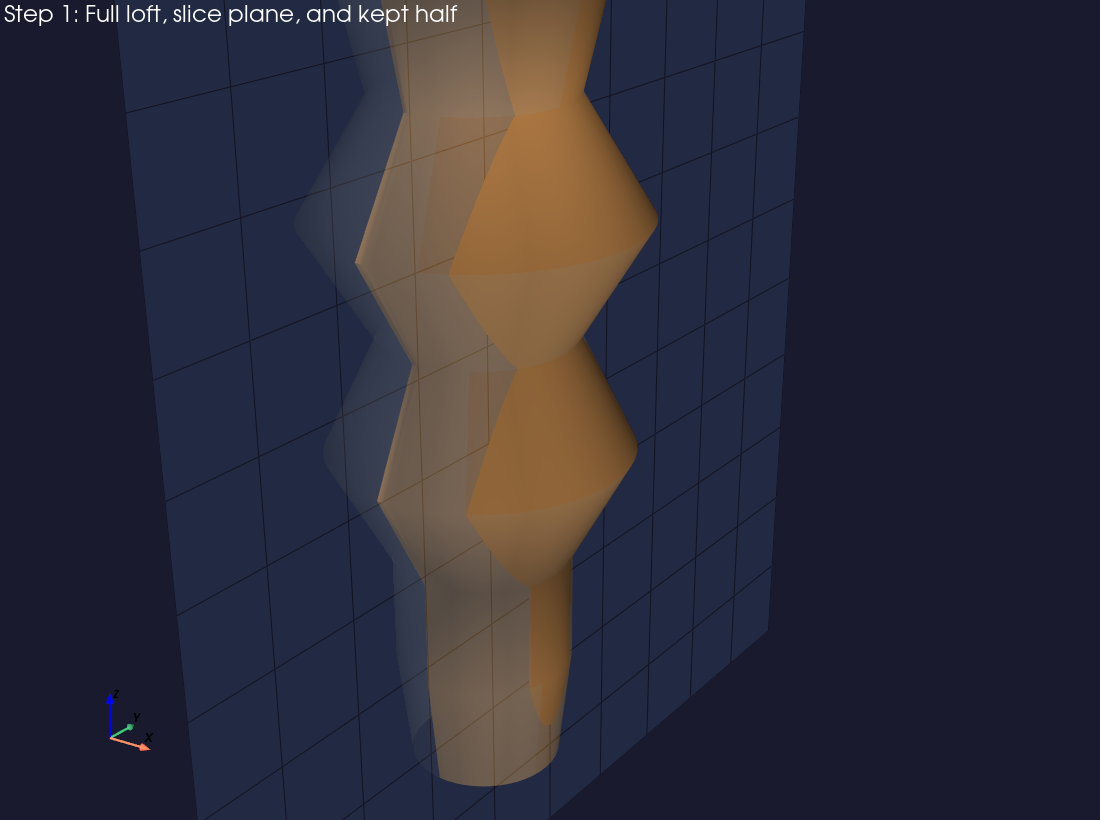

In [6]:
plane_size = 1.15 * max(
    full_surface.bounds[1] - full_surface.bounds[0],
    full_surface.bounds[3] - full_surface.bounds[2],
    full_surface.bounds[5] - full_surface.bounds[4],
)
slice_plane = pv.Plane(
    center=half_surface.center,
    direction=active_surface_config.slice_normal,
    i_size=plane_size,
    j_size=plane_size,
)

show_step(
    "Step 1: Loft the circles and clip the shape in half",
    "The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.",
)
display_static_scene(
    title="Step 1: Full loft, slice plane, and kept half",
    bounds=full_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            full_surface,
            {
                "color": "#d9d9d9",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            slice_plane,
            {
                "color": "#6aa9ff",
                "opacity": 0.25,
                "show_edges": True,
            },
        ),
        (
            half_surface,
            {
                "color": "#ffb366",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)


### Step 2: Seed the padded box for the bounded Voronoi construction

The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.

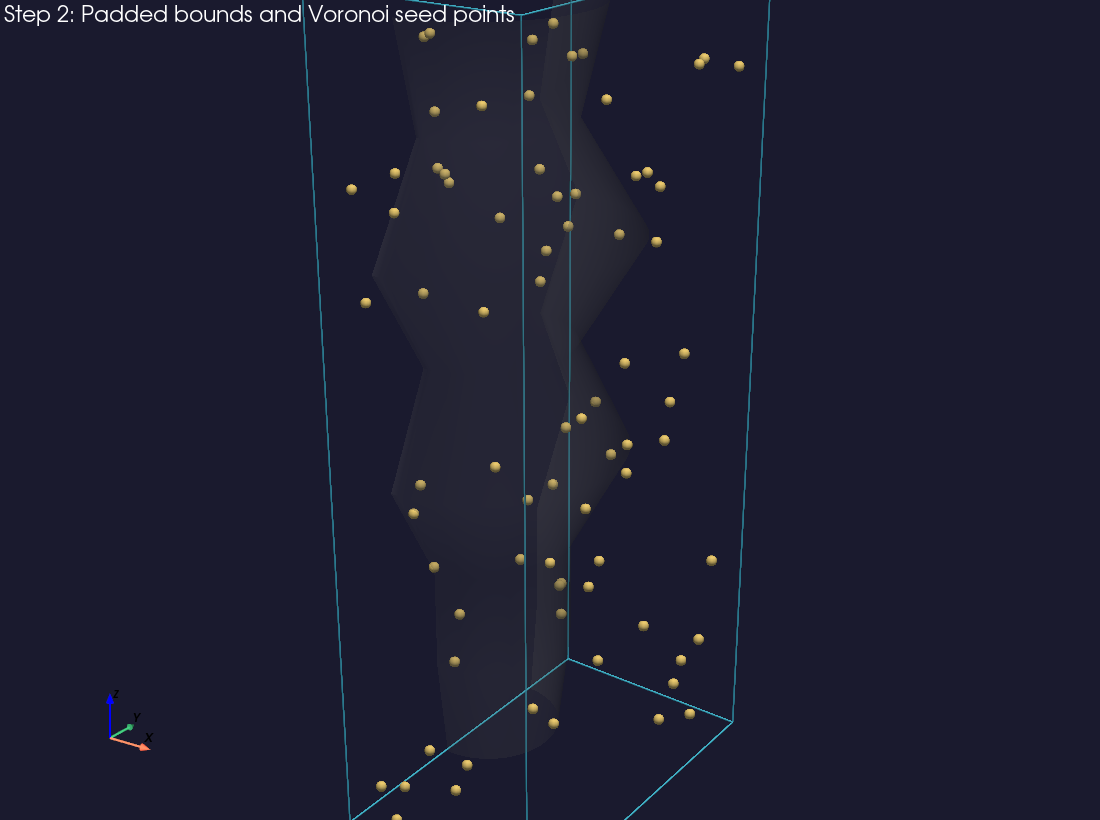

In [7]:
padded_box_edges = pv.Box(bounds=padded_bounds).extract_all_edges()

show_step(
    "Step 2: Seed the padded box for the bounded Voronoi construction",
    "The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.",
)
display_static_scene(
    title="Step 2: Padded bounds and Voronoi seed points",
    bounds=padded_bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#8c8c8c",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            padded_box_edges,
            {
                "color": "#4dd7ff",
                "line_width": 2,
                "opacity": 0.95,
            },
        ),
    ],
    point_sets=[
        (
            seed_points,
            {
                "color": "#ffe082",
                "point_size": 11,
                "render_points_as_spheres": True,
                "opacity": 1.0,
            },
        ),
    ],
)


### Step 3: View every rebuilt intersection polyline as a separate colored trace

Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.

Raw intersection loops: 52
Retained intersection loops after neighbor filter: 51
Rebuilt line polylines used downstream: 51
Discarded isolated loops: 1


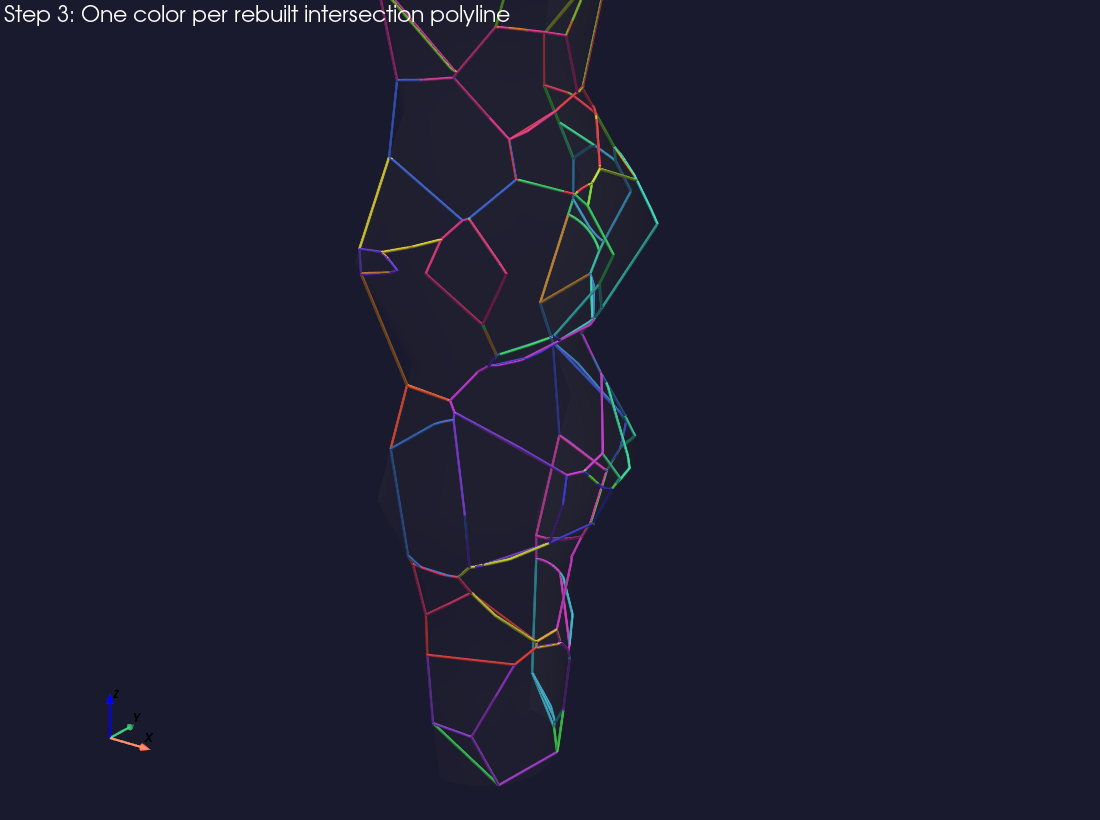

### Step 3A: Interactive inspection of the rebuilt intersection polylines

This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.

In [8]:
show_step(
    "Step 3: View every rebuilt intersection polyline as a separate colored trace",
    "Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.",
)
print(f"Raw intersection loops: {len(raw_closed_polylines)}")
print(f"Retained intersection loops after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(analysis_original_polylines)}")
print(f"Discarded isolated loops: {len(discarded_polyline_indices)}")
display_static_scene(
    title="Step 3: One color per rebuilt intersection polyline",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
)
show_step(
    "Step 3A: Interactive inspection of the rebuilt intersection polylines",
    "This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.",
)
display_interactive_scene(
    title="Step 3A: Interactive rebuilt intersection polylines",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
    zoom_factor=1.15,
    window_size=(1300, 950),
)


In [9]:
show_step(
    "Step 4: Optional subset browser",
    "Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact working polyline you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between the preview loft bands and the generated output surfaces.",
)
print(f"Working polylines available in the browser: {len(analysis_followup_polylines)}")
print("Curve value 0 hides all curves and generated outputs.")
make_curve_subset_browser()


### Step 4: Optional subset browser

Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact working polyline you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between the preview loft bands and the generated output surfaces.

Working polylines available in the browser: 51
Curve value 0 hides all curves and generated outputs.


### Step 5: Show the generated open surface patches before merging

This cell keeps the original patch result visible on its own. Each large rebuilt polyline now generates two consecutive loft bands: base to the first moved scaled curve, then first moved scaled curve to the second moved scaled curve at `0.9` of the first scale factor. The extrusion vector still comes only from the fitted-circle center shift around the initial loft bounding-box center.

Average volume/length ratio: 7.8474
Extrusion multiplier: -1.00
Large-curve loft surface faces: 2112
Small-curve fan surface faces: 360


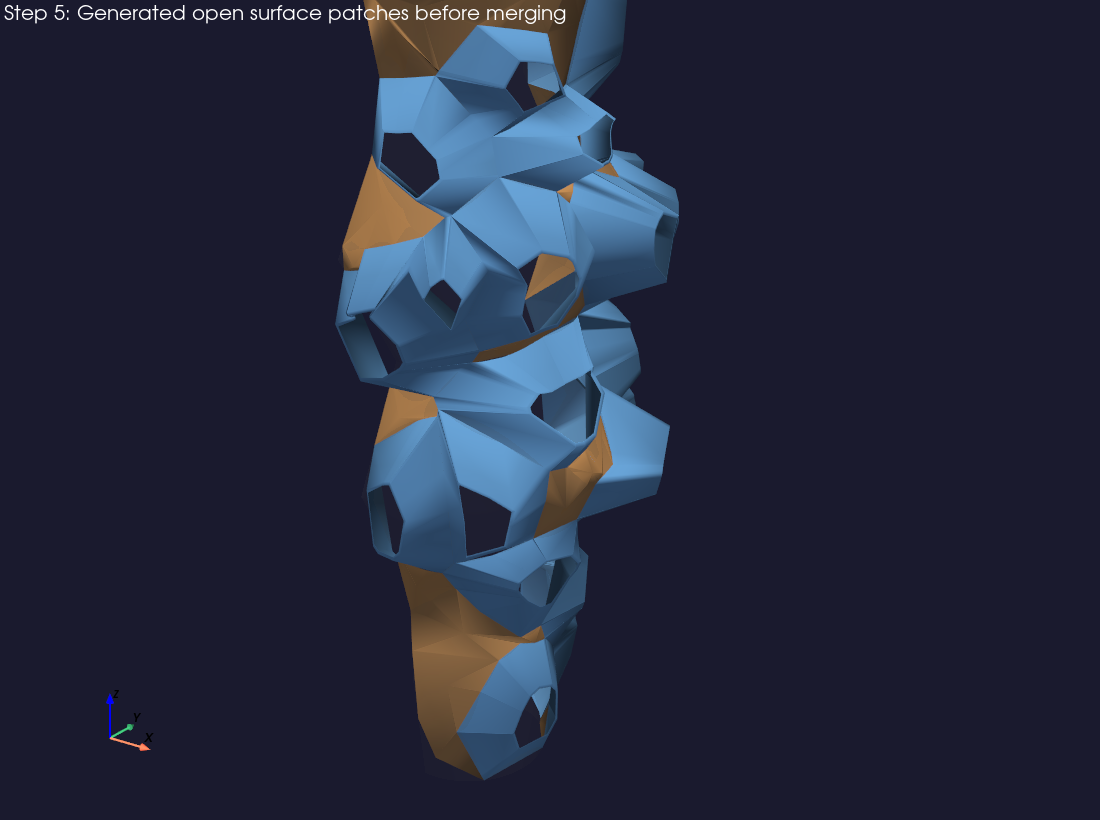

### Step 5A: Interactive inspection of the unmerged geometry

This opens the unmerged open patches in a native PyVista window so you can orbit, pan, and zoom the geometry before any merge or later scaling is applied.

In [10]:
generated_surface = curve_result.generated_surface if curve_result.generated_surface.n_points else half_surface

generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

show_step(
    "Step 5: Show the generated open surface patches before merging",
    "This cell keeps the original patch result visible on its own. Each large rebuilt polyline now generates two consecutive loft bands: base to the first moved scaled curve, then first moved scaled curve to the second moved scaled curve at `0.9` of the first scale factor. The extrusion vector still comes only from the fitted-circle center shift around the initial loft bounding-box center.",
)
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier: {extrusion_multiplier:.2f}")
print(f"Large-curve loft surface faces: {curve_result.larger_surface.n_cells}")
print(f"Small-curve fan surface faces: {curve_result.smaller_surface.n_cells}")
display_static_scene(
    title="Step 5: Generated open surface patches before merging",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.1,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.larger_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.smaller_surface,
            {
                "color": "#d9a066",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)
show_step(
    "Step 5A: Interactive inspection of the unmerged geometry",
    "This opens the unmerged open patches in a native PyVista window so you can orbit, pan, and zoom the geometry before any merge or later scaling is applied.",
)
display_interactive_scene(
    title="Step 5A: Interactive unmerged open patches before scaling",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.1,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.larger_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
        (
            curve_result.smaller_surface,
            {
                "color": "#d9a066",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=1.2,
    window_size=(1300, 950),
)


### Step 6: Merge the separate open patches into one larger open unit

This merge starts from the already-open patch result shown in the previous step, so it does not introduce any end caps. The goal here is only to join the existing open surfaces into one larger open geometry while keeping the holes and other naked boundaries available for the later operations.

Merged open unit faces: 2472
Merged open unit connected regions: 1
Scaling origin from initial loft bounding box center: [0.0, 0.0, 46.830000000000005]


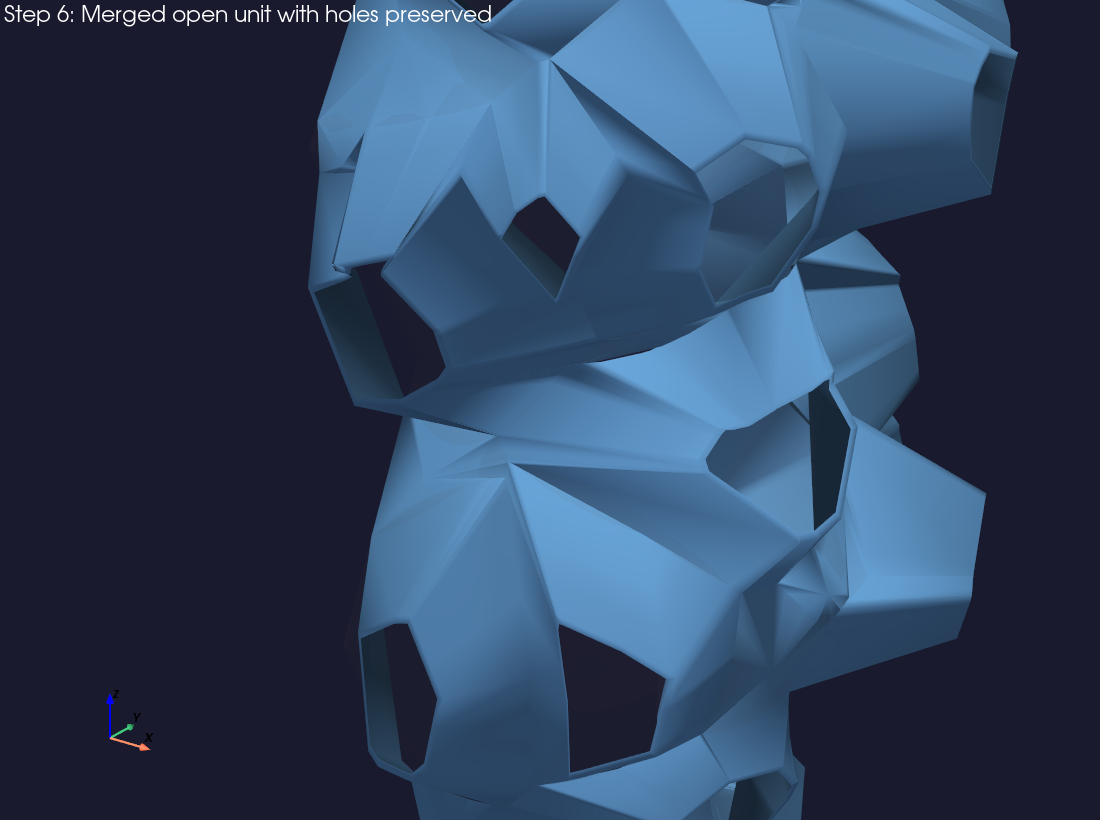

### Step 6A: Interactive inspection of the merged open unit

This opens the merged open unit in a native PyVista window so you can orbit, pan, and zoom the geometry after merging but before creating the scaled copy.

In [11]:
# Merge the previously generated open patches into one larger open unit.
# The merge source is the already-open generated patch surface, not the capped per-curve outputs.
joined_unit_open_surface = curve_result.generated_surface.copy(deep=True) if curve_result.generated_surface.n_points else pv.PolyData()
joined_unit_scene_bounds = padded_scene_bounds(
    joined_unit_open_surface.bounds if joined_unit_open_surface.n_points else generated_bounds,
    padding_fraction=0.04,
    min_padding=0.8,
)
joined_region_count = count_connected_regions(joined_unit_open_surface)

show_step(
    "Step 6: Merge the separate open patches into one larger open unit",
    "This merge starts from the already-open patch result shown in the previous step, so it does not introduce any end caps. The goal here is only to join the existing open surfaces into one larger open geometry while keeping the holes and other naked boundaries available for the later operations.",
)
print(f"Merged open unit faces: {joined_unit_open_surface.n_cells}")
print(f"Merged open unit connected regions: {joined_region_count}")
print(f"Scaling origin from initial loft bounding box center: {initial_loft_bbox_center.tolist()}")
display_static_scene(
    title="Step 6: Merged open unit with holes preserved",
    bounds=joined_unit_scene_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.06,
                "smooth_shading": True,
            },
        ),
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=2.4,
)
show_step(
    "Step 6A: Interactive inspection of the merged open unit",
    "This opens the merged open unit in a native PyVista window so you can orbit, pan, and zoom the geometry after merging but before creating the scaled copy.",
)
display_interactive_scene(
    title="Step 6A: Interactive merged open unit before scaling",
    bounds=joined_unit_scene_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.06,
                "smooth_shading": True,
            },
        ),
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=1.25,
    window_size=(1300, 950),
)


### Step 7: Make the scaled second open unit

This cell takes the already merged open unit and builds a second open unit by scaling it in `X` and `Y` around the center of the initial full loft bounding box while keeping `Z` unchanged.

Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 46.830000000000005]
Scaled open unit faces: 2472
Scaled open unit connected regions: 1


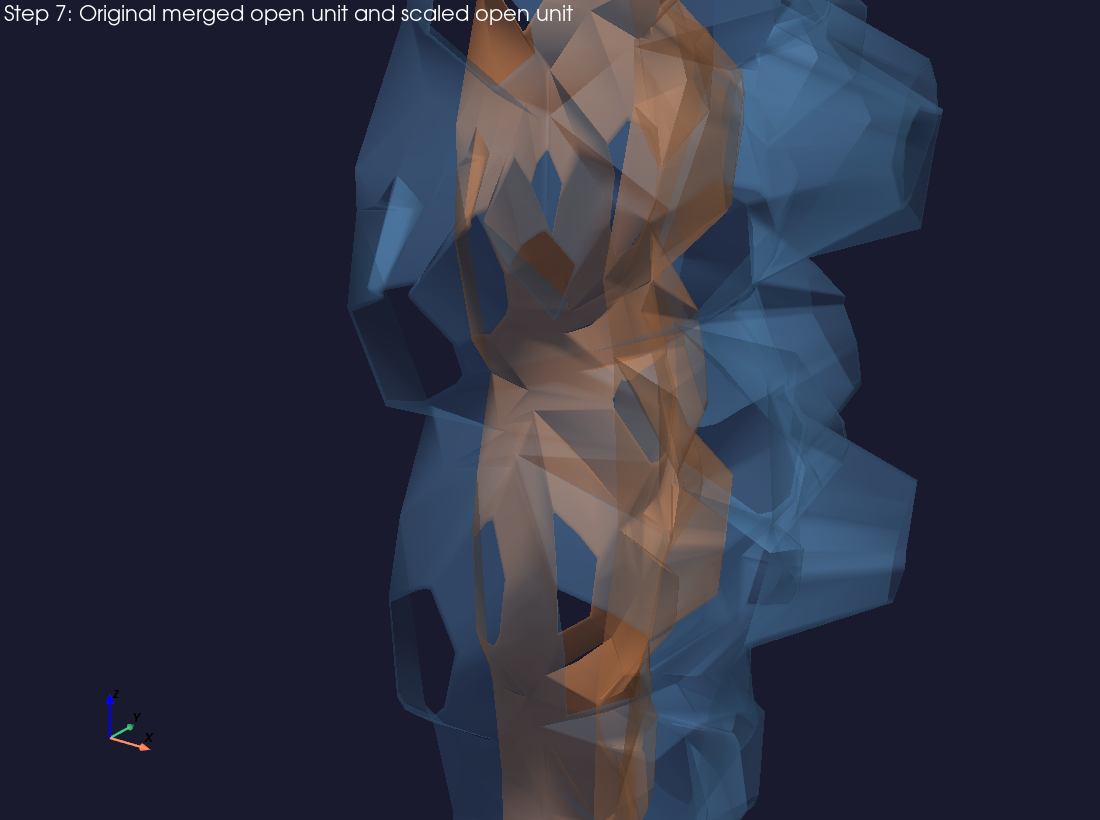

In [12]:
# Create the second open unit by scaling the merged geometry in X and Y while leaving Z unchanged.
# The scaling pivot is the center of the initial full-loft bounding box.
scaled_unit_surface = scale_polydata_in_xy(
    joined_unit_open_surface,
    center=initial_loft_bbox_center,
    scale_x=scale_x,
    scale_y=scale_y,
)
scaled_unit_region_count = count_connected_regions(scaled_unit_surface)
joined_and_scaled_surface = _merge_meshes(
    [mesh for mesh in [joined_unit_open_surface, scaled_unit_surface] if mesh.n_cells > 0]
)
joined_and_scaled_bounds = padded_scene_bounds(
    joined_and_scaled_surface.bounds if joined_and_scaled_surface.n_points else joined_unit_scene_bounds,
    padding_fraction=0.06,
    min_padding=0.8,
)

show_step(
    "Step 7: Make the scaled second open unit",
    "This cell takes the already merged open unit and builds a second open unit by scaling it in `X` and `Y` around the center of the initial full loft bounding box while keeping `Z` unchanged.",
)
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Scaled open unit faces: {scaled_unit_surface.n_cells}")
print(f"Scaled open unit connected regions: {scaled_unit_region_count}")
display_static_scene(
    title="Step 7: Original merged open unit and scaled open unit",
    bounds=joined_and_scaled_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 0.45,
                "smooth_shading": True,
            },
        ),
        (
            scaled_unit_surface,
            {
                "color": "#f59f66",
                "opacity": 0.75,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=2.1,
)


### Step 8: Inspect the naked edges on both open units

The cyan curves are the naked edges of the merged source unit and the magenta curves are the naked edges of the scaled unit. This is the checkpoint for verifying that the boundaries you are about to loft are really just the exterior loops and intended holes, now with the scaled copy derived from the initial loft bounding-box center.

Source naked edge loops: 49
Scaled naked edge loops: 49


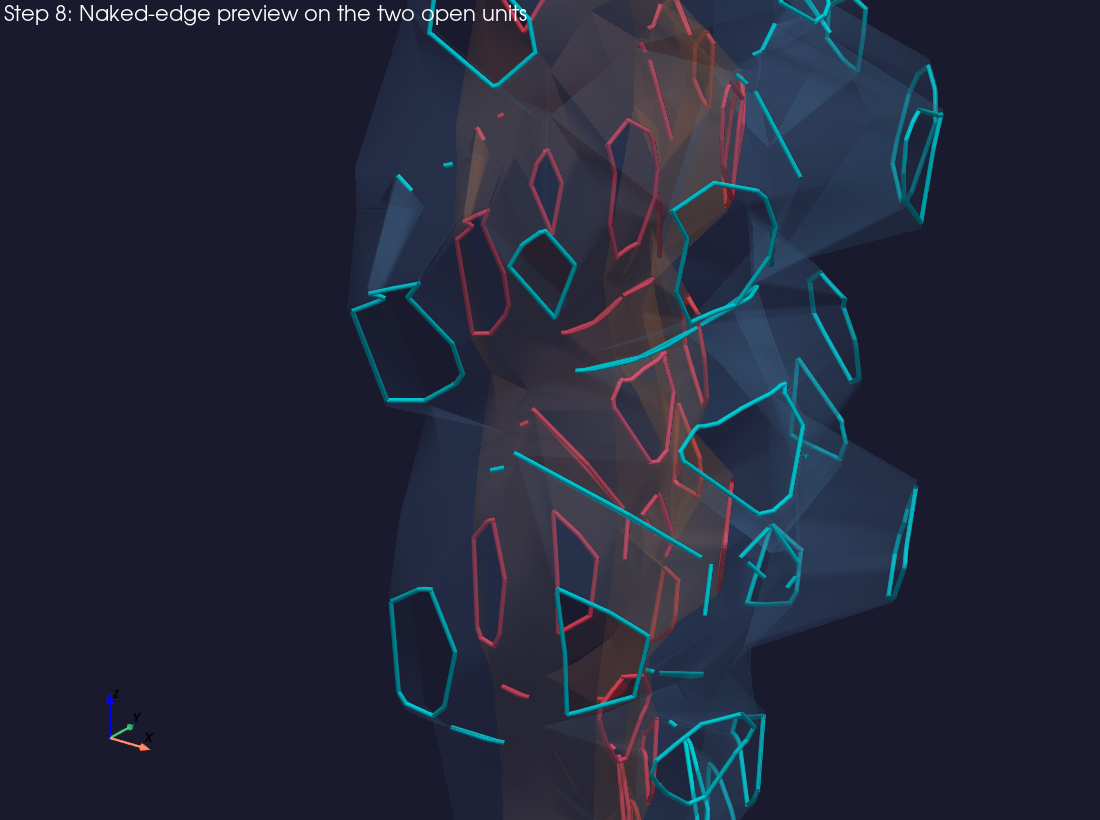

In [13]:
# Inspect the naked edges on both open units before lofting between them.
source_naked_edge_mesh, source_naked_edge_loops = extract_naked_edge_loops(
    joined_unit_open_surface,
    tolerance=active_surface_config.line_tolerance,
)
scaled_naked_edge_mesh, scaled_naked_edge_loops = extract_naked_edge_loops(
    scaled_unit_surface,
    tolerance=active_surface_config.line_tolerance,
)
scaled_source_naked_edge_loops = [
    scale_points_in_xy(
        loop,
        center=initial_loft_bbox_center,
        scale_x=scale_x,
        scale_y=scale_y,
    )
    for loop in source_naked_edge_loops
]
scaled_source_naked_edge_mesh = build_polyline_mesh(scaled_source_naked_edge_loops)

show_step(
    "Step 8: Inspect the naked edges on both open units",
    "The cyan curves are the naked edges of the merged source unit and the magenta curves are the naked edges of the scaled unit. This is the checkpoint for verifying that the boundaries you are about to loft are really just the exterior loops and intended holes, now with the scaled copy derived from the initial loft bounding-box center.",
)
print(f"Source naked edge loops: {len(source_naked_edge_loops)}")
print(f"Scaled naked edge loops: {len(scaled_naked_edge_loops)}")
display_static_scene(
    title="Step 8: Naked-edge preview on the two open units",
    bounds=joined_and_scaled_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            scaled_unit_surface,
            {
                "color": "#f59f66",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            source_naked_edge_mesh,
            {
                "color": "#00e5ff",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
        (
            scaled_naked_edge_mesh,
            {
                "color": "#ff4d6d",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=2.1,
)


### Step 9: Loft between the naked edges and assemble the shell

This final cell keeps the notebook's current shell assembly, then adds the extra naked-edge loft surface from the uniform-cap test path before checking the remaining open boundaries. The added test loft is drawn in bright green so you can see exactly where it sits relative to the merged shell.

Current notebook boundary loft faces: 1294
Additional test boundary loft faces: 238
Assembled shell faces: 6476
Assembled shell connected regions: 1
Remaining naked edge loops after assembly: 0


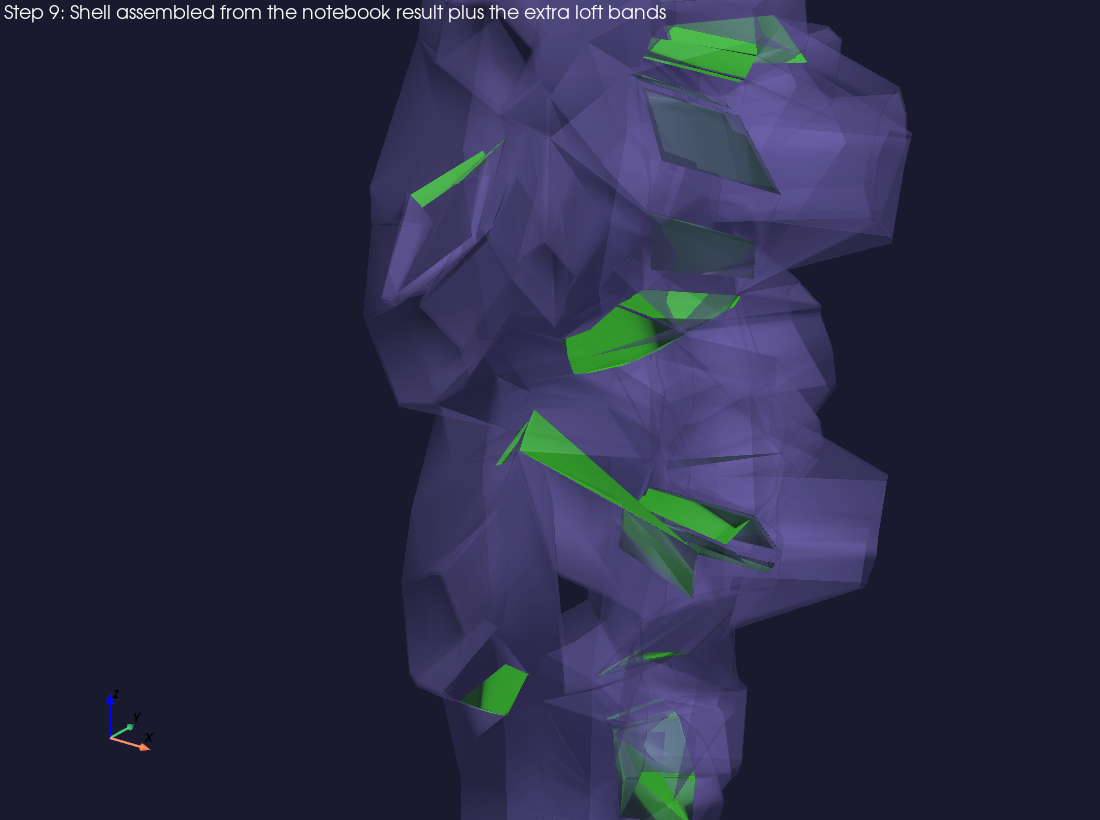

In [14]:
# Loft between the matching naked-edge loops, then merge those loft bands with the current notebook result.
boundary_loft_meshes = [
    _loft_between_polylines(source_loop, target_loop)
    for source_loop, target_loop in zip(source_naked_edge_loops, scaled_source_naked_edge_loops)
]
boundary_loft_surface = _merge_meshes(boundary_loft_meshes)
experimental_boundary_loft_surface = (
    curve_result.uniform_cap_edge_loft_surface.copy(deep=True)
    if curve_result.uniform_cap_edge_loft_surface.n_points
    else pv.PolyData()
)
closed_shell_surface = _merge_meshes(
    [
        mesh
        for mesh in [
            joined_unit_open_surface,
            scaled_unit_surface,
            boundary_loft_surface,
            experimental_boundary_loft_surface,
        ]
        if mesh.n_cells > 0
    ]
)
closed_region_count = count_connected_regions(closed_shell_surface)
final_naked_edge_mesh, final_naked_edge_loops = extract_naked_edge_loops(
    closed_shell_surface,
    tolerance=active_surface_config.line_tolerance,
)
closed_shell_bounds = padded_scene_bounds(
    closed_shell_surface.bounds if closed_shell_surface.n_points else joined_and_scaled_bounds,
    padding_fraction=0.05,
    min_padding=0.8,
)

show_step(
    "Step 9: Loft between the naked edges and assemble the shell",
    "This final cell keeps the notebook's current shell assembly, then adds the extra naked-edge loft surface from the uniform-cap test path before checking the remaining open boundaries. The added test loft is drawn in bright green so you can see exactly where it sits relative to the merged shell.",
)
print(f"Current notebook boundary loft faces: {boundary_loft_surface.n_cells}")
print(f"Additional test boundary loft faces: {experimental_boundary_loft_surface.n_cells}")
print(f"Assembled shell faces: {closed_shell_surface.n_cells}")
print(f"Assembled shell connected regions: {closed_region_count}")
print(f"Remaining naked edge loops after assembly: {len(final_naked_edge_loops)}")
display_static_scene(
    title="Step 9: Shell assembled from the notebook result plus the extra loft bands",
    bounds=closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 0.35,
                "smooth_shading": True,
            },
        ),
        (
            experimental_boundary_loft_surface,
            {
                "color": "#39ff14",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 6,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=1.9,
)


In [ ]:
# Show the assembled geometry in an interactive 3D viewer so you can orbit, pan, and zoom.
show_step(
    "Step 10: Interactive 3D inspection of the assembled geometry",
    "This interactive check now opens in a native PyVista window instead of the notebook html backend, because the installed PyVista version still requires `trame` for that notebook path. The native window supports orbit, pan, and zoom without that extra dependency. The extra test loft is shown in bright green on top of the semi-transparent assembled shell.",
)
display_interactive_scene(
    title="Step 10: Interactive assembled geometry",
    bounds=closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 0.3,
                "smooth_shading": True,
            },
        ),
        (
            experimental_boundary_loft_surface,
            {
                "color": "#39ff14",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=2.0,
    window_size=(1300, 950),
)


### Step 10: Interactive 3D inspection of the assembled geometry

This interactive check now opens in a native PyVista window instead of the notebook html backend, because the installed PyVista version still requires `trame` for that notebook path. The native window supports orbit, pan, and zoom without that extra dependency. The extra test loft is shown in bright green on top of the semi-transparent assembled shell.

In [16]:
# Export the assembled geometry to STL.
default_stl_path = Path("exports") / "lofted_surface_voronoi_shell.stl"
exported_stl_path = export_mesh_to_stl(closed_shell_surface, default_stl_path)
print(f"STL exported to: {exported_stl_path}")


STL exported to: exports\lofted_surface_voronoi_shell.stl
